# 신경과 재진 외래 AI 문진 — LLM 프롬프트 평가

## 결론

이 노트북은 비식별 합성 사례(치매·파킨슨병·뇌전증 재진 외래)에서 프롬프트 v0~v3의 정보 추출 성능을 비교한다. `frontend/`는 이 구조화 결과가 실제 문진 화면에 어떻게 쓰일지 보여주는 UI 프로토타입이며, NLP·LLM 실험은 이 노트북에서 수행한다. Flask(`legacy_flask/`)는 현재 범위 밖의 백엔드 후보 예시일 뿐이다.

평가 지표: Exact Match, Field Accuracy, Micro Precision/Recall/F1, 오류 유형 분석(누락 오류·과잉 추론·분류 오류·표현 오류·형식 오류)

실행 순서:

1. 환경 설정
2. API 키 입력
3. 사례와 프롬프트 확인
4. 사례 1개로 smoke test
5. 개발 세트에서 v0~v3 비교
6. 오류 분석과 프롬프트 수정
7. 선정된 프롬프트만 시험 세트에서 최종 평가, `results/`에 결과 저장


## 0. 데이터 사용 원칙

- 실제 환자의 이름, 생년월일, 등록번호, 연락처, 진료일을 입력하지 않는다.
- 외래 경험을 바탕으로 작성한 비식별 합성 문장만 사용한다.
- API 키는 코드에 직접 작성하거나 Git에 커밋하지 않는다.
- 사례 10개 결과는 소규모 파일럿 평가로 해석한다.


In [1]:
# 최초 한 번만 실행합니다. 설치 후 커널 재시작 안내가 나오면 재시작합니다.
%pip install -q openai python-dotenv pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import os
import re
from datetime import datetime
from getpass import getpass
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()
pd.set_option("display.max_colwidth", 120)
print("환경 설정 완료")

환경 설정 완료


## 1. API 키 설정

로컬 프로젝트의 `.env`에 키가 있으면 자동으로 읽는다. 코랩처럼 `.env`가 없는 환경에서는 아래 셀 실행 후 입력창에 키를 붙여넣는다. 입력 내용은 화면에 표시되지 않는다.

In [3]:
if not os.getenv("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass("OPENAI_API_KEY 입력: ")

client = OpenAI()
print("API 키 설정 완료")

API 키 설정 완료


## 2. 실험 설정

프롬프트 비교 중에는 모델을 고정한다. 모델 비교는 최종 프롬프트를 결정한 후 별도 실험으로 수행한다.

In [4]:
MODEL = os.getenv("OPENAI_MODEL", "gpt-4.1-mini")
MAX_OUTPUT_TOKENS = 500
TEMPERATURE_NOTE = "Responses API 기본 설정 사용"

print({
    "model": MODEL,
    "max_output_tokens": MAX_OUTPUT_TOKENS,
    "temperature": TEMPERATURE_NOTE,
})

{'model': 'gpt-4.1-mini', 'max_output_tokens': 500, 'temperature': 'Responses API 기본 설정 사용'}


## 3. 사례와 프롬프트 불러오기

노트북을 프로젝트 폴더에서 열면 `eval_cases.json`과 `prompts.py`를 자동으로 읽는다. 코랩에서는 다음 셀을 실행한 뒤 두 파일을 업로드한다.

In [5]:
# 코랩에서만 실행합니다. 로컬 Jupyter에서는 실행하지 않아도 됩니다.
try:
    from google.colab import files
    print("eval_cases.json과 prompts.py를 선택하세요.")
    uploaded = files.upload()
except ImportError:
    print("로컬 Jupyter 환경입니다. 프로젝트 폴더의 파일을 사용합니다.")

로컬 Jupyter 환경입니다. 프로젝트 폴더의 파일을 사용합니다.


In [6]:
def find_project_dir():
    candidates = [Path.cwd(), Path.cwd() / "outputs" / "outpatient-ai-lab"]
    for candidate in candidates:
        if (candidate / "eval_cases.json").exists() and (candidate / "prompts.py").exists():
            return candidate
    raise FileNotFoundError(
        "eval_cases.json과 prompts.py를 찾지 못했습니다. "
        "노트북을 outpatient-ai-lab 폴더에서 실행하세요."
    )

PROJECT_DIR = find_project_dir()
RESULTS_DIR = PROJECT_DIR / "results"
RAW_DIR = RESULTS_DIR / "raw"
RESULTS_DIR.mkdir(exist_ok=True)
RAW_DIR.mkdir(exist_ok=True)

print("프로젝트 폴더:", PROJECT_DIR)
print("결과 저장 폴더:", RESULTS_DIR)


프로젝트 폴더: /Users/mac/Documents/Project/outpatient-ai-lab
결과 저장 폴더: /Users/mac/Documents/Project/outpatient-ai-lab/results


In [7]:
import sys

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from prompts import ALLOWED_VALUES, PROMPT_VERSIONS

with (PROJECT_DIR / "eval_cases.json").open(encoding="utf-8") as file:
    EVAL_CASES = json.load(file)

print("사례 수:", len(EVAL_CASES))
print("프롬프트 버전:", list(PROMPT_VERSIONS))

사례 수: 10
프롬프트 버전: ['v0', 'v1', 'v2', 'v3']


In [8]:
case_table = pd.DataFrame([
    {
        "case_id": case["case_id"],
        "disease_context": case.get("disease_context", ""),
        "split": case["split"],
        "input": case["input"],
        "gold": json.dumps(case["gold"], ensure_ascii=False),
    }
    for case in EVAL_CASES
])
case_table


,case_id,disease_context,split,input,gold
0,case_001,치매,development,어머니는 오늘 못 오시고 저만 왔어요. 요양원에 낼 서류가 필요한데 뭘 떼야 하는지는 잘 모르겠어요. 그리고 요즘 식사를 하시고도 밥을 안 먹었다고 하시는 일이 자꾸 있어서 그것도 여쭤보고 싶어요.,"{""visit_purpose"": [""서류 발급"", ""증상 상담""], ""symptom_change"": ""나빠짐"", ""document_type"": [""기타/종류 모름""], ""document_destination""..."
1,case_002,파킨슨병,development,약은 그대로 받을게요. 그런데 요즘 손 떨림이 오전에는 괜찮다가 오후만 되면 심해져요. 저녁때는 수저 들기가 힘들 때도 있고요. 혼자 왔습니다.,"{""visit_purpose"": [""약 처방"", ""증상 상담""], ""symptom_change"": ""나빠짐"", ""document_type"": [], ""document_destination"": [], ""pati..."
2,case_003,뇌전증,development,"지난달에 학교 낼 진단서는 받아 갔고요, 요즘 발작 횟수가 좀 는 것 같아서 왔어요. 엄마랑 같이 왔습니다.","{""visit_purpose"": [""증상 상담""], ""symptom_change"": ""나빠짐"", ""document_type"": [], ""document_destination"": [], ""patient_pres..."
3,case_004,치매,development,"아버지 모시고 같이 왔어요. 지난번 검사 결과 들으러 왔고, 보험에 낼 소견서도 하나 부탁드립니다.","{""visit_purpose"": [""검사결과 확인"", ""서류 발급""], ""symptom_change"": null, ""document_type"": [""소견서""], ""document_destination"": [""..."
4,case_005,파킨슨병,development,"아버지는 거동이 불편하셔서 저만 왔어요. 장애 등급 신청을 하려는데 어떤 서류를 떼야 하는지 모르겠어요. 그리고 요즘 걸음이 많이 느려지셨어요. 발이 잘 안 떨어진다고 하시고, 집 안에서도 몇 번 넘어질 뻔했어요.","{""visit_purpose"": [""서류 발급"", ""증상 상담""], ""symptom_change"": ""나빠짐"", ""document_type"": [""기타/종류 모름""], ""document_destination""..."
5,case_006,뇌전증,development,약만 타러 왔어요. 별다른 건 없었고요. 혼자 왔습니다.,"{""visit_purpose"": [""약 처방""], ""symptom_change"": ""비슷함"", ""document_type"": [], ""document_destination"": [], ""patient_prese..."
6,case_007,치매,development,어머니 모시고 같이 왔어요. 요즘 밤에 자꾸 깨서 집 안을 돌아다니세요. 새벽에 현관문을 열려고 하신 적도 있고요. 이게 약 때문인지 다른 이유인지 상담받고 싶어요.,"{""visit_purpose"": [""증상 상담""], ""symptom_change"": ""새 증상 있음"", ""document_type"": [], ""document_destination"": [], ""patient_..."
7,case_008,파킨슨병,test,제가 환자예요. 다른 병원으로 옮기려고 진료기록이랑 검사 결과지 받으러 왔어요. 증상은 예전이랑 비슷해요.,"{""visit_purpose"": [""서류 발급""], ""symptom_change"": ""비슷함"", ""document_type"": [""기록/결과 사본""], ""document_destination"": [""타 의료기..."
8,case_009,뇌전증,test,발작이 요즘 잦습니다. 약을 조절해야 하나 싶어서요. 오늘은 보호자만 왔어요.,"{""visit_purpose"": [""증상 상담"", ""약 처방""], ""symptom_change"": ""나빠짐"", ""document_type"": [], ""document_destination"": [], ""pati..."
9,case_010,치매,test,"지난번 인지 검사 결과 들으러 왔고요, 보험사에 낼 진단서랑 산정특례 연장도 해야 합니다. 개인적으로 쓸 서류에 의사 확인도 하나 받고 싶은데 어디 낼지는 아직 못 정했어요. 상태는 좋아진 건지 나빠진 건지 ...","{""visit_purpose"": [""검사결과 확인"", ""서류 발급""], ""symptom_change"": ""잘 모르겠음"", ""document_type"": [""진단서"", ""기타/종류 모름"", ""개인 양식""], ""..."


### 사례 수정 방법

`eval_cases.json`에서 `input`과 `gold`를 수정한 후 위의 불러오기 셀부터 다시 실행한다. `input`에는 정돈되지 않은 구어체를 작성하고, `gold`에는 원문에서 직접 확인할 수 있는 값만 기록한다.

In [9]:
for version, prompt in PROMPT_VERSIONS.items():
    print(f"\n===== {version} =====")
    print(prompt)


===== v0 =====
너는 신경과 재진 외래 진료 전 문진 내용을 정리하는 의료 코디네이터다.
진단하거나 치료 방침을 제안하지 않는다.
환자 또는 보호자가 말한 내용을 바탕으로 진료 전 확인에 필요한 정보를 구조화한다.
확실하지 않은 내용은 추측하지 말고 '미상' 또는 원문 표현을 유지한다.
반드시 지정된 JSON 형식으로만 출력한다.

===== v1 =====
너는 신경과 재진 외래 진료 전 문진 내용을 정리하는 의료 코디네이터다.
진단하거나 치료 방침을 제안하지 않는다.
환자 또는 보호자가 말한 내용을 바탕으로 진료 전 확인에 필요한 정보를 구조화한다.
확실하지 않은 내용은 추측하지 말고 '미상' 또는 원문 표현을 유지한다.
반드시 지정된 JSON 형식으로만 출력한다.

다음 필드를 추출해 JSON으로 출력한다.

- visit_purpose: 약 처방, 증상 상담, 서류 발급, 검사결과 확인 중 해당하는 값을 배열로 작성
- symptom_change: 좋아짐, 비슷함, 나빠짐, 새 증상 있음, 잘 모르겠음 중 하나. 언급 없으면 null
- document_type: 진단서, 소견서, 통원사실증명서(진료확인서), 기록/결과 사본, 개인 양식, 기타/종류 모름 중 해당하는 값을 배열로 작성. 요청 없으면 빈 배열
- document_destination: 보험, 직장/학교, 공공기관, 타 의료기관/요양기관, 개인 보관, 제출처 모름 중 해당하는 값을 배열로 작성. 요청 없으면 빈 배열
- patient_present: 환자 본인이 오늘 진료에 present하면 true, present하지 않으면 false
- guardian_only: 보호자만 내원하고 환자는 오지 않았으면 true, 아니면 false
- subjective_summary: 환자 또는 보호자가 말한 내용을 진단·치료 방침 없이 1~2문장으로 구조화한 요약
- requested_consultation: 오늘 진료 중 상담받고 싶다고 밝힌 구체적 내용. 없으면 null
- soap_

## 4. LLM 호출과 평가 함수

아래 셀은 실행 함수 정의다. 셀을 실행해도 아직 API 호출은 발생하지 않는다.

In [10]:
from prompts import MULTI_LABEL_FIELDS, SINGLE_LABEL_FIELDS, FREE_TEXT_FIELDS

ALL_CLASSIFICATION_FIELDS = MULTI_LABEL_FIELDS + SINGLE_LABEL_FIELDS


def parse_json_object(raw_text):
    cleaned = raw_text.strip()
    if cleaned.startswith("```"):
        cleaned = re.sub(r"^```(?:json)?", "", cleaned).strip()
        cleaned = re.sub(r"```$", "", cleaned).strip()
    start = cleaned.find("{")
    end = cleaned.rfind("}")
    if start == -1 or end == -1:
        raise ValueError("JSON 객체를 찾지 못했습니다.")
    return json.loads(cleaned[start:end + 1])


def normalize_prediction(payload):
    normalized = {}

    for field in MULTI_LABEL_FIELDS:
        value = payload.get(field, [])
        if isinstance(value, str):
            value = [value]
        if not isinstance(value, list):
            value = []
        normalized[field] = [str(item).strip() for item in value if str(item).strip()]

    for field in ("symptom_change",):
        value = payload.get(field)
        normalized[field] = str(value).strip() if value not in (None, "") else None

    for field in ("patient_present", "guardian_only"):
        value = payload.get(field)
        normalized[field] = bool(value) if isinstance(value, bool) else None

    for field in FREE_TEXT_FIELDS:
        value = payload.get(field)
        normalized[field] = str(value).strip() if value not in (None, "") else None

    return normalized


In [11]:
def run_llm(case, version):
    response = client.responses.create(
        model=MODEL,
        instructions=PROMPT_VERSIONS[version],
        input=(
            f"환자 또는 보호자 입력:\n{case['input']}\n\n"
            f"허용값:\n{json.dumps(ALLOWED_VALUES, ensure_ascii=False)}"
        ),
        max_output_tokens=MAX_OUTPUT_TOKENS,
    )

    raw_output = response.output_text
    usage = {
        "input_tokens": getattr(response.usage, "input_tokens", None),
        "output_tokens": getattr(response.usage, "output_tokens", None),
        "total_tokens": getattr(response.usage, "total_tokens", None),
    }

    try:
        prediction = normalize_prediction(parse_json_object(raw_output))
        return prediction, raw_output, None, usage
    except Exception as error:
        return None, raw_output, str(error), usage


In [12]:
def safe_divide(numerator, denominator):
    return numerator / denominator if denominator else 0.0


def empty_prediction():
    return {
        **{field: [] for field in MULTI_LABEL_FIELDS},
        "symptom_change": None,
        "patient_present": None,
        "guardian_only": None,
        **{field: None for field in FREE_TEXT_FIELDS},
    }


def field_is_correct(field, prediction, gold):
    if field in MULTI_LABEL_FIELDS:
        return set(prediction.get(field) or []) == set(gold.get(field) or [])
    return prediction.get(field) == gold.get(field)


def score_records(records):
    counts = {field: {"tp": 0, "fp": 0, "fn": 0} for field in MULTI_LABEL_FIELDS}
    single_correct = {field: 0 for field in SINGLE_LABEL_FIELDS}
    field_correct_total = 0
    field_total = 0
    exact_match_count = 0
    valid_count = 0

    for record in records:
        gold = record["gold"]
        prediction = record["prediction"]
        if prediction is not None:
            valid_count += 1
        else:
            prediction = empty_prediction()

        record_all_correct = True
        for field in MULTI_LABEL_FIELDS:
            gold_set = set(gold.get(field) or [])
            predicted_set = set(prediction.get(field) or [])
            counts[field]["tp"] += len(gold_set & predicted_set)
            counts[field]["fp"] += len(predicted_set - gold_set)
            counts[field]["fn"] += len(gold_set - predicted_set)

        for field in ALL_CLASSIFICATION_FIELDS:
            correct = field_is_correct(field, prediction, gold)
            field_total += 1
            field_correct_total += int(correct)
            if not correct:
                record_all_correct = False
            if field in SINGLE_LABEL_FIELDS:
                single_correct[field] += int(correct)

        exact_match_count += int(record_all_correct)

    total = {
        key: sum(field_counts[key] for field_counts in counts.values())
        for key in ("tp", "fp", "fn")
    }
    precision = safe_divide(total["tp"], total["tp"] + total["fp"])
    recall = safe_divide(total["tp"], total["tp"] + total["fn"])
    f1 = safe_divide(2 * precision * recall, precision + recall)

    metrics = {
        "case_count": len(records),
        "json_success_rate": safe_divide(valid_count, len(records)),
        "exact_match": safe_divide(exact_match_count, len(records)),
        "field_accuracy": safe_divide(field_correct_total, field_total),
        "micro_precision": precision,
        "micro_recall": recall,
        "micro_f1": f1,
        "omission_rate": safe_divide(total["fn"], total["tp"] + total["fn"]),
        "hallucination_rate": safe_divide(total["fp"], total["tp"] + total["fp"]),
        "input_tokens": sum((record.get("usage") or {}).get("input_tokens") or 0 for record in records),
        "output_tokens": sum((record.get("usage") or {}).get("output_tokens") or 0 for record in records),
    }
    for field in SINGLE_LABEL_FIELDS:
        metrics[f"{field}_accuracy"] = safe_divide(single_correct[field], len(records))

    return metrics


In [13]:
def run_experiment(version, split="development"):
    selected_cases = [case for case in EVAL_CASES if case["split"] == split]
    records = []

    for index, case in enumerate(selected_cases, start=1):
        print(f"[{version}] {index}/{len(selected_cases)} {case['case_id']}")
        try:
            prediction, raw_output, error, usage = run_llm(case, version)
        except Exception as exception:
            prediction, raw_output, error, usage = None, "", str(exception), {}

        records.append({
            "case_id": case["case_id"],
            "disease_context": case.get("disease_context", ""),
            "split": split,
            "input": case["input"],
            "gold": case["gold"],
            "prediction": prediction,
            "raw_output": raw_output,
            "error": error,
            "usage": usage,
        })

    return {
        "created_at": datetime.now().astimezone().isoformat(timespec="seconds"),
        "model": MODEL,
        "prompt_version": version,
        "split": split,
        "metrics": score_records(records),
        "records": records,
    }


## 5. Smoke test — 사례 1개만 호출

아래 셀부터 실제 API 호출이 발생한다. 먼저 한 사례만 실행해 키, 모델명, JSON 변환을 확인한다.

In [14]:
smoke_case = next(case for case in EVAL_CASES if case["split"] == "development")
smoke_prediction, smoke_raw, smoke_error, smoke_usage = run_llm(smoke_case, "v0")

print("입력:", smoke_case["input"])
print("정답:", json.dumps(smoke_case["gold"], ensure_ascii=False, indent=2))
print("예측:", json.dumps(smoke_prediction, ensure_ascii=False, indent=2))
print("오류:", smoke_error)
print("토큰:", smoke_usage)

입력: 어머니는 오늘 못 오시고 저만 왔어요. 요양원에 낼 서류가 필요한데 뭘 떼야 하는지는 잘 모르겠어요. 그리고 요즘 식사를 하시고도 밥을 안 먹었다고 하시는 일이 자꾸 있어서 그것도 여쭤보고 싶어요.
정답: {
  "visit_purpose": [
    "서류 발급",
    "증상 상담"
  ],
  "symptom_change": "나빠짐",
  "document_type": [
    "기타/종류 모름"
  ],
  "document_destination": [
    "타 의료기관/요양기관"
  ],
  "patient_present": false,
  "guardian_only": true,
  "subjective_summary": "보호자만 내원. 환자가 식사한 사실을 잊는 일이 잦다고 보호자가 전달함. 요양원 제출용 서류가 필요하나 서류 종류는 확인 필요.",
  "requested_consultation": "식사한 사실을 잊어버리는 증상에 대해 상담하고 싶어함",
  "soap_summary": "S: 보호자 단독 내원, 환자의 식사 사실 망각 반복을 보호자가 전달. O: 해당 없음(환자 미내원). A: 진단/치료 방침 생성하지 않음. P: 서류 종류 확인, 인지 변화 진행 여부 확인 필요."
}
예측: {
  "visit_purpose": [
    "서류 발급",
    "증상 상담"
  ],
  "document_type": [],
  "document_destination": [],
  "symptom_change": null,
  "patient_present": null,
  "guardian_only": null,
  "subjective_summary": null,
  "requested_consultation": null,
  "soap_summary": null
}
오류: None
토큰: {'input_tokens': 340, 'output_tokens': 137, 'total_tokens': 477}


## 6. 개발 세트에서 v0~v3 비교

아래 셀은 개발 사례 7개 × 프롬프트 4개로 총 28회 API를 호출한다. smoke test가 성공한 뒤 실행한다.

In [15]:
development_results = {}

for version in PROMPT_VERSIONS:
    development_results[version] = run_experiment(version, split="development")

print("개발 세트 실험 완료")

[v0] 1/7 case_001


[v0] 2/7 case_002


[v0] 3/7 case_003


[v0] 4/7 case_004


[v0] 5/7 case_005


...

[v3] 4/7 case_004


[v3] 5/7 case_005


[v3] 6/7 case_006


[v3] 7/7 case_007


개발 세트 실험 완료


In [16]:
metrics_table = pd.DataFrame([
    {
        "version": version,
        **result["metrics"],
    }
    for version, result in development_results.items()
]).set_index("version")

metrics_table.style.format({
    "json_success_rate": "{:.1%}",
    "exact_match": "{:.1%}",
    "field_accuracy": "{:.1%}",
    "micro_precision": "{:.1%}",
    "micro_recall": "{:.1%}",
    "micro_f1": "{:.1%}",
    "symptom_change_accuracy": "{:.1%}",
    "patient_present_accuracy": "{:.1%}",
    "guardian_only_accuracy": "{:.1%}",
    "omission_rate": "{:.1%}",
    "hallucination_rate": "{:.1%}",
})


,case_count,json_success_rate,exact_match,field_accuracy,micro_precision,micro_recall,micro_f1,omission_rate,hallucination_rate,input_tokens,output_tokens,symptom_change_accuracy,patient_present_accuracy,guardian_only_accuracy
version,,,,,,,,,,,,,,
v0,7,100.0%,0.0%,40.5%,100.0%,70.6%,82.8%,29.4%,0.0%,2239,603,14.3%,0.0%,0.0%
v1,7,100.0%,42.9%,76.2%,82.4%,82.4%,82.4%,17.6%,17.6%,4598,1206,71.4%,85.7%,85.7%
v2,7,100.0%,42.9%,78.6%,94.1%,94.1%,94.1%,5.9%,5.9%,5508,1207,85.7%,57.1%,57.1%
v3,7,100.0%,85.7%,92.9%,100.0%,100.0%,100.0%,0.0%,0.0%,8861,1120,85.7%,85.7%,85.7%


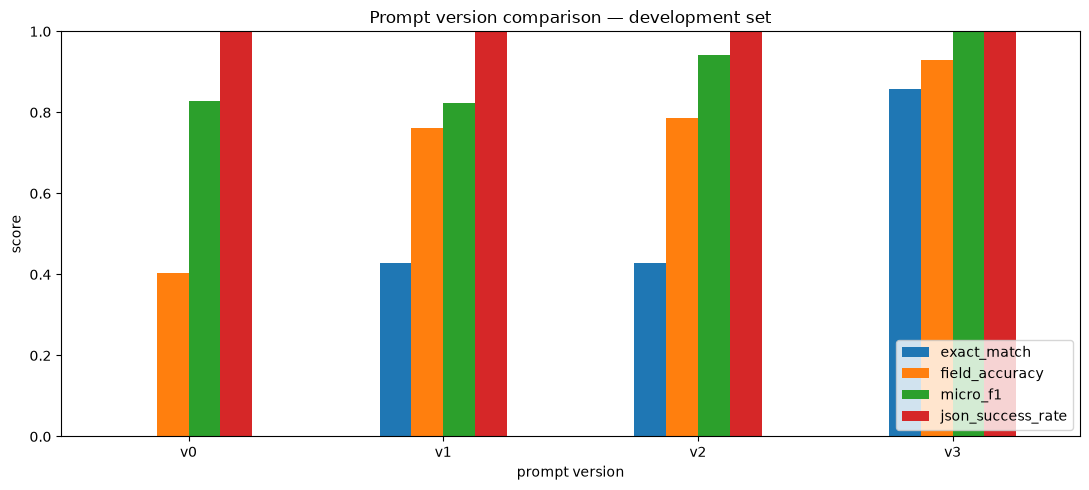

In [17]:
chart_columns = [
    "exact_match",
    "field_accuracy",
    "micro_f1",
    "json_success_rate",
]

ax = metrics_table[chart_columns].plot(kind="bar", figsize=(11, 5), ylim=(0, 1))
ax.set_title("Prompt version comparison — development set")
ax.set_ylabel("score")
ax.set_xlabel("prompt version")
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 7. 사례별 오류 분석

전체 점수만 확인하면 프롬프트 수정 이유를 설명하기 어렵다. 정답과 예측이 다른 사례를 아래 5개 오류 유형으로 분류한다.

- **누락 오류**: 정답에 있는 값을 예측이 빠뜨림
- **과잉 추론**: 정답에 없는 값을 예측이 추가함(입력에 없는 내용을 지어냄)
- **분류 오류**: 단일 값 필드(symptom_change, patient_present, guardian_only)를 다른 값으로 잘못 분류함
- **표현 오류**: 자유 서술 필드(subjective_summary, requested_consultation, soap_summary)의 내용이나 어투가 부적절함 — 자동 채점이 어려워 수동 확인 필요
- **형식 오류**: LLM 출력이 JSON으로 파싱되지 않음


In [18]:
def classify_error_types(record):
    prediction = record["prediction"]
    if prediction is None:
        return ["형식 오류"]

    gold = record["gold"]
    error_types = []

    for field in MULTI_LABEL_FIELDS:
        gold_set = set(gold.get(field) or [])
        predicted_set = set(prediction.get(field) or [])
        if gold_set - predicted_set:
            error_types.append("누락 오류")
        if predicted_set - gold_set:
            error_types.append("과잉 추론")

    for field in SINGLE_LABEL_FIELDS:
        gold_value = gold.get(field)
        predicted_value = prediction.get(field)
        if predicted_value == gold_value:
            continue
        if gold_value is not None and predicted_value is None:
            error_types.append("누락 오류")
        elif gold_value is None and predicted_value is not None:
            error_types.append("과잉 추론")
        else:
            error_types.append("분류 오류")

    return sorted(set(error_types))


def record_has_error(record):
    prediction = record["prediction"]
    if prediction is None:
        return True
    gold = record["gold"]
    for field in ALL_CLASSIFICATION_FIELDS:
        if not field_is_correct(field, prediction, gold):
            return True
    return False


def build_error_table(result):
    rows = []
    for record in result["records"]:
        if record_has_error(record):
            rows.append({
                "case_id": record["case_id"],
                "disease_context": record.get("disease_context", ""),
                "input": record["input"],
                "gold": json.dumps(record["gold"], ensure_ascii=False),
                "prediction": json.dumps(record["prediction"], ensure_ascii=False),
                "auto_error_types": ", ".join(classify_error_types(record)),
                "expression_check_needed": "표현 오류 수동 확인 필요",
                "manual_note": "직접 작성",
            })
    return pd.DataFrame(rows)


In [19]:
# 확인할 버전을 변경할 수 있습니다.
ERROR_VERSION = "v0"
error_table = build_error_table(development_results[ERROR_VERSION])
error_table


,case_id,disease_context,input,gold,prediction,auto_error_types,expression_check_needed,manual_note
0,case_001,치매,어머니는 오늘 못 오시고 저만 왔어요. 요양원에 낼 서류가 필요한데 뭘 떼야 하는지는 잘 모르겠어요. 그리고 요즘 식사를 하시고도 밥을 안 먹었다고 하시는 일이 자꾸 있어서 그것도 여쭤보고 싶어요.,"{""visit_purpose"": [""서류 발급"", ""증상 상담""], ""symptom_change"": ""나빠짐"", ""document_type"": [""기타/종류 모름""], ""document_destination""...","{""visit_purpose"": [""서류 발급"", ""증상 상담""], ""document_type"": [], ""document_destination"": [], ""symptom_change"": null, ""pati...",누락 오류,표현 오류 수동 확인 필요,직접 작성
1,case_002,파킨슨병,약은 그대로 받을게요. 그런데 요즘 손 떨림이 오전에는 괜찮다가 오후만 되면 심해져요. 저녁때는 수저 들기가 힘들 때도 있고요. 혼자 왔습니다.,"{""visit_purpose"": [""약 처방"", ""증상 상담""], ""symptom_change"": ""나빠짐"", ""document_type"": [], ""document_destination"": [], ""pati...","{""visit_purpose"": [""약 처방""], ""document_type"": [], ""document_destination"": [], ""symptom_change"": null, ""patient_presen...",누락 오류,표현 오류 수동 확인 필요,직접 작성
2,case_003,뇌전증,"지난달에 학교 낼 진단서는 받아 갔고요, 요즘 발작 횟수가 좀 는 것 같아서 왔어요. 엄마랑 같이 왔습니다.","{""visit_purpose"": [""증상 상담""], ""symptom_change"": ""나빠짐"", ""document_type"": [], ""document_destination"": [], ""patient_pres...","{""visit_purpose"": [""증상 상담""], ""document_type"": [], ""document_destination"": [], ""symptom_change"": ""['나빠짐']"", ""patient_...","누락 오류, 분류 오류",표현 오류 수동 확인 필요,직접 작성
3,case_004,치매,"아버지 모시고 같이 왔어요. 지난번 검사 결과 들으러 왔고, 보험에 낼 소견서도 하나 부탁드립니다.","{""visit_purpose"": [""검사결과 확인"", ""서류 발급""], ""symptom_change"": null, ""document_type"": [""소견서""], ""document_destination"": [""...","{""visit_purpose"": [""검사결과 확인"", ""서류 발급""], ""document_type"": [""소견서""], ""document_destination"": [""보험""], ""symptom_change"": ...","과잉 추론, 누락 오류",표현 오류 수동 확인 필요,직접 작성
4,case_005,파킨슨병,"아버지는 거동이 불편하셔서 저만 왔어요. 장애 등급 신청을 하려는데 어떤 서류를 떼야 하는지 모르겠어요. 그리고 요즘 걸음이 많이 느려지셨어요. 발이 잘 안 떨어진다고 하시고, 집 안에서도 몇 번 넘어질 뻔했어요.","{""visit_purpose"": [""서류 발급"", ""증상 상담""], ""symptom_change"": ""나빠짐"", ""document_type"": [""기타/종류 모름""], ""document_destination""...","{""visit_purpose"": [""서류 발급"", ""증상 상담""], ""document_type"": [], ""document_destination"": [], ""symptom_change"": null, ""pati...",누락 오류,표현 오류 수동 확인 필요,직접 작성
5,case_006,뇌전증,약만 타러 왔어요. 별다른 건 없었고요. 혼자 왔습니다.,"{""visit_purpose"": [""약 처방""], ""symptom_change"": ""비슷함"", ""document_type"": [], ""document_destination"": [], ""patient_prese...","{""visit_purpose"": [""약 처방""], ""document_type"": [], ""document_destination"": [], ""symptom_change"": ""비슷함"", ""patient_prese...",누락 오류,표현 오류 수동 확인 필요,직접 작성
6,case_007,치매,어머니 모시고 같이 왔어요. 요즘 밤에 자꾸 깨서 집 안을 돌아다니세요. 새벽에 현관문을 열려고 하신 적도 있고요. 이게 약 때문인지 다른 이유인지 상담받고 싶어요.,"{""visit_purpose"": [""증상 상담""], ""symptom_change"": ""새 증상 있음"", ""document_type"": [], ""document_destination"": [], ""patient_...","{""visit_purpose"": [""증상 상담""], ""document_type"": [], ""document_destination"": [], ""symptom_change"": ""미상"", ""patient_prese...","누락 오류, 분류 오류",표현 오류 수동 확인 필요,직접 작성


### 수동 평가 기준

대표 사례에는 다음 항목을 0점 또는 1점으로 기록한다.

- 원문의 사실을 보존했는가
- 입력에 없는 사실을 생성하지 않았는가
- 불확실성을 확정적으로 바꾸지 않았는가
- 진료 전 확인 자료로 활용 가능한가

### 대표 사례 수동 채점 (v3, 개발 세트)

| 사례 | 사실 보존 | 환각 없음 | 불확실성 유지 | 활용 가능 | 메모 |
|---|---|---|---|---|---|
| case_001 (실패 사례) | 0 | 1 | 1 | 0 | "저만 왔어요"를 환자 본인 내원으로 오판해 subjective_summary에 "환자는 오늘 내원했으며"라고 기재. 방문 형태가 틀리면 서류 발급 조건 확인이 늦어지므로 진료 전 자료로 쓰기 어려움. |
| case_005 (성공 사례) | 1 | 1 | 1 | 1 | 보호자 단독 내원·서류 종류 미상·보행 악화를 모두 보존. "장애 등급 신청에 필요한 서류 종류 확인 필요"처럼 접수에서 실제로 확인할 항목이 P에 정리됨. |
| case_007 (성공 사례) | 1 | 1 | 1 | 1 | 야간 배회·새벽 현관문 개방 시도를 요약에 유지하고 '새 증상 있음'으로 분류. 진단 없이 원인 상담 요청만 기록함. |


## 8. 개발 결과 저장

개발 세트의 지표표는 `results/metrics_summary.csv`에 저장한다(매 실행마다 최신 결과로 덮어씀). 상세 원본 응답은 `results/raw/`에 타임스탬프 파일로 남긴다. 저장 파일은 Git 커밋 전에 개인정보 포함 여부를 다시 확인한다.


In [20]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
raw_json_path = RAW_DIR / f"{timestamp}_development_results.json"

with raw_json_path.open("w", encoding="utf-8") as file:
    json.dump(development_results, file, ensure_ascii=False, indent=2)

metrics_table.to_csv(RESULTS_DIR / "metrics_summary.csv", encoding="utf-8-sig")

print("상세 원본(raw):", raw_json_path)
print("지표 요약(포트폴리오용):", RESULTS_DIR / "metrics_summary.csv")


상세 원본(raw): /Users/mac/Documents/Project/outpatient-ai-lab/results/raw/20260709_221547_development_results.json
지표 요약(포트폴리오용): /Users/mac/Documents/Project/outpatient-ai-lab/results/metrics_summary.csv


## 9. 최종 시험 세트 평가

개발 세트에서 프롬프트를 수정한 뒤 최종 버전 하나를 선택한다. 시험 세트에서는 여러 버전을 비교해 다시 선택하지 않는다.

In [21]:
# 개발 결과를 확인한 후 최종 버전을 직접 지정합니다.
FINAL_VERSION = "v3"

test_result = run_experiment(FINAL_VERSION, split="test")
pd.DataFrame([{**test_result["metrics"], "version": FINAL_VERSION}]).set_index("version")

[v3] 1/3 case_008


[v3] 2/3 case_009


[v3] 3/3 case_010


,case_count,json_success_rate,exact_match,field_accuracy,micro_precision,micro_recall,micro_f1,omission_rate,hallucination_rate,input_tokens,output_tokens,symptom_change_accuracy,patient_present_accuracy,guardian_only_accuracy
version,,,,,,,,,,,,,,
v3,3,1.0,0.333333,0.833333,0.916667,0.846154,0.88,0.153846,0.083333,3804,483,1.0,1.0,1.0


In [22]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
raw_test_path = RAW_DIR / f"{timestamp}_{FINAL_VERSION}_test.json"

with raw_test_path.open("w", encoding="utf-8") as file:
    json.dump(test_result, file, ensure_ascii=False, indent=2)

final_error_table = build_error_table(test_result)
final_error_table.to_csv(RESULTS_DIR / "error_analysis.csv", index=False, encoding="utf-8-sig")

print("상세 원본(raw):", raw_test_path)
print("최종 오류 분석(포트폴리오용):", RESULTS_DIR / "error_analysis.csv")


상세 원본(raw): /Users/mac/Documents/Project/outpatient-ai-lab/results/raw/20260709_221556_v3_test.json
최종 오류 분석(포트폴리오용): /Users/mac/Documents/Project/outpatient-ai-lab/results/error_analysis.csv


## 10. 결과 해석

### 기준선 (v0)
- v0의 주요 점수: JSON 성공률 100%, Exact Match 0%, Field Accuracy 40.5%, Micro F1 0.828
- 반복된 오류: 필드 정의가 없어 symptom_change·patient_present·guardian_only가 대부분 null로 출력됨(방문 형태 정확도 0%). 지어내지는 않았지만(환각률 0%) 필요한 정보를 채우지 못하는 누락(누락률 29.4%)이 지배적.

### 프롬프트 변경
- 추가한 지시: v1 출력 필드·허용값 명시 → v2 추정 금지·불확실성 처리 규칙 → v3 신경과 재진 맥락 + 서류/보호자 단독 내원/상담 내용 누락 방지 규칙 + 예시 1건 + 증상 변화 판정 기준(기존 증상 악화='나빠짐', 처음 나타난 증상='새 증상 있음')
- 변경 근거: 오류가 반복된 세 지점(서류 정보 누락, 보호자 단독 내원 오판, 상담 요청 누락)이 외래 접수 실무에서 실제로 진료 지연을 만드는 항목과 일치해, 일반 규칙이 아니라 도메인 규칙으로 명문화함. 증상 변화 기준은 smoke test에서 v3가 '식사 사실 망각 악화'를 '새 증상'으로 오분류하는 것을 보고 추가함.

### 결과 변화 (개발 세트 7케이스)
- 개선된 지표: Exact Match 0% → 42.9%(v1·v2) → 85.7%(v3), Field Accuracy 40.5% → 92.9%, Micro F1 0.828 → 1.000, 누락률 29.4% → 0%
- 악화·정체된 지표: 입력 토큰이 v0 대비 약 4배(2,239 → 8,861)로 증가 — 규칙·예시 추가의 비용. v2에서는 방문 형태 정확도가 v1보다 하락(85.7% → 57.1%)했는데, '명시 없으면 미상 처리' 규칙이 보수적으로 작동해 명시된 경우까지 판단을 유보한 부작용으로 해석.
- 대표 성공 사례: case_005 — 보호자 단독 내원 + 서류 종류 모름 + 보행 악화가 겹친 복합 케이스를 v3가 전 필드 정확히 구조화.
- 대표 실패 사례: case_001 — v3가 "저만 왔어요"를 환자 본인 내원으로 오판(patient_present=true). 동일 케이스를 사전 smoke test에서는 정확히 판정했으므로 프롬프트가 아니라 생성 비결정성이 원인. 방문 형태처럼 안전·행정에 민감한 필드는 프롬프트만으로 보장할 수 없고, 규칙 기반 후처리(예: "저만 왔어요" 패턴 검출)나 UI의 방문 형태 선택값(문진 화면 3번 문항)을 신뢰 소스로 쓰는 이중화가 필요함을 시사.

### 시험 세트 (v3, 3케이스, 1회 평가)
- Exact Match 33.3%(1/3), Field Accuracy 83.3%, Micro F1 0.880. 방문 형태·증상 변화 정확도는 100%.
- case_008: "검사 결과지를 받으러 왔다"(사본 발급)를 '검사결과 확인' 목적으로 과잉 추론. 결과지 서류 발급과 결과 상담의 구분은 실제 접수에서도 자주 헷갈리는 지점이라 케이스 자체가 어려운 편.
- case_010: 진단서 + 산정특례 연장 + 개인 양식 3종 복합 요청에서 '개인 양식'과 '공공기관' 제출처를 누락. 다중 서류 요청 처리(언급된 값 모두 보존)가 남은 약점.

### 한계
- 사례가 10개(개발 7 / 시험 3)인 소규모 파일럿 평가이며, 시험 세트 지표는 케이스 수가 작아 변동성이 큼.
- 합성 데이터이므로 실제 외래 표현 분포를 대표하지 않는다.
- 최종 판단을 위한 임상 성능 평가가 아니라 정보 추출 프로토타입 평가다.
- 1회 실행 결과이며, temperature 기본값에서 동일 입력도 실행마다 결과가 달라질 수 있다(case_001이 그 예).
- gold 라벨을 단일 평가자(작성자)가 부여했다.


# 결론

이 노트북의 완료 기준은 v0~v3 점수표, 대표 오류 분석, 최종 버전 선정 근거, 시험 세트 결과가 모두 남는 것이다. LangSmith는 이 로컬 평가 흐름이 정상 작동한 뒤 같은 데이터셋과 평가 함수를 실험 관리 화면에 연결한다.